In [1]:
# Step 1: Import Qiskit libraries and set up Aer simulator

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

SIM = AerSimulator()

In [2]:
# Step 2: Set common parameters for fair comparison

N_BITS = 200
rng = np.random.default_rng()   # no seed = fully random each run

In [3]:
# Step 3: Run BB84

# --- Alice: random bits and bases ---
alice_bits = rng.integers(0, 2, N_BITS)
alice_bases = rng.choice(['Z', 'X'], size=N_BITS)

# --- Bob: random measurement bases ---
bob_bases = rng.choice(['Z', 'X'], size=N_BITS)

def encode_qubit(bit, basis):
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)
    if basis == 'X':
        qc.h(0)
    return qc

def measure_qubit(qc, basis):
    if basis == 'X':
        qc.h(0)
    qc.measure(0, 0)
    return qc

bob_results = []
for i in range(N_BITS):
    qc = encode_qubit(alice_bits[i], alice_bases[i])
    qc = measure_qubit(qc, bob_bases[i])
    result = SIM.run(qc, shots=1, memory=True).result()
    outcome = int(result.get_memory()[0])
    bob_results.append(outcome)
bob_results = np.array(bob_results)

# --- Sifting ---
sift_mask = alice_bases == bob_bases
alice_sifted_bb84 = alice_bits[sift_mask]
bob_sifted_bb84 = bob_results[sift_mask]

# --- QBER ---
mismatches_bb84 = np.sum(alice_sifted_bb84 != bob_sifted_bb84)
qber_bb84 = mismatches_bb84 / len(alice_sifted_bb84)

print("BB84 done.")
print(f"Sifted key length : {len(alice_sifted_bb84)}")
print(f"QBER              : {qber_bb84:.4f}")
print(f"Keys match        : {np.array_equal(alice_sifted_bb84, bob_sifted_bb84)}")

BB84 done.
Sifted key length : 102
QBER              : 0.0000
Keys match        : True


In [4]:
# Step 4: Run LM05

# --- Bob: random bits and bases (initial preparation) ---
bob_bits_lm05 = rng.integers(0, 2, N_BITS)
bob_bases_lm05 = rng.choice(['Z', 'X'], size=N_BITS)

# --- Alice: random mode, CM bases, message bits ---
alice_modes = rng.choice(['CM', 'MM'], size=N_BITS)
alice_cm_bases = rng.choice(['Z', 'X'], size=N_BITS)
alice_message_bits = rng.integers(0, 2, N_BITS)

def prepare_qubit(bit, basis):
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)
    if basis == 'X':
        qc.h(0)
    return qc

def alice_cm_measure(qc, basis):
    if basis == 'X':
        qc.h(0)
    qc.measure(0, 0)
    return qc

def alice_mm_encode(qc, message_bit):
    if message_bit == 1:
        qc.y(0)
    return qc

def bob_final_measure(qc, basis):
    if basis == 'X':
        qc.h(0)
    qc.measure(0, 0)
    return qc

cm_results = []
mm_bob_decoded = []

for i in range(N_BITS):
    qc = prepare_qubit(bob_bits_lm05[i], bob_bases_lm05[i])

    if alice_modes[i] == 'CM':
        qc = alice_cm_measure(qc, alice_cm_bases[i])
        result = SIM.run(qc, shots=1, memory=True).result()
        outcome = int(result.get_memory()[0])
        cm_results.append(outcome)
    else:  # MM
        qc = alice_mm_encode(qc, alice_message_bits[i])
        qc = bob_final_measure(qc, bob_bases_lm05[i])
        result = SIM.run(qc, shots=1, memory=True).result()
        outcome = int(result.get_memory()[0])
        decoded_bit = 0 if outcome == bob_bits_lm05[i] else 1
        mm_bob_decoded.append(decoded_bit)

cm_results = np.array(cm_results)
mm_bob_decoded = np.array(mm_bob_decoded)

# --- Control Mode QBER check ---
cm_mask = alice_modes == 'CM'
cm_bob_bits = bob_bits_lm05[cm_mask]
cm_bob_bases = bob_bases_lm05[cm_mask]
cm_alice_bases = alice_cm_bases[cm_mask]
basis_match_mask = cm_alice_bases == cm_bob_bases
cm_checkable_bob = cm_bob_bits[basis_match_mask]
cm_checkable_alice = cm_results[basis_match_mask]

cm_mismatches = np.sum(cm_checkable_alice != cm_checkable_bob)
qber_lm05 = cm_mismatches / len(cm_checkable_alice)

# --- Sifted key (Message Mode only) ---
mm_mask = alice_modes == 'MM'
alice_sifted_lm05 = alice_message_bits[mm_mask]
bob_sifted_lm05 = mm_bob_decoded

print("LM05 done.")
print(f"Sifted key length : {len(alice_sifted_lm05)}")
print(f"QBER              : {qber_lm05:.4f}")
print(f"Keys match        : {np.array_equal(alice_sifted_lm05, bob_sifted_lm05)}")

LM05 done.
Sifted key length : 100
QBER              : 0.0000
Keys match        : True


In [5]:
# Step 5: Print side-by-side summary table

print(f"{'Metric':<20}{'BB84':<15}{'LM05':<15}")
print("-" * 50)
print(f"{'Raw qubits sent':<20}{N_BITS:<15}{N_BITS:<15}")
print(f"{'Sifted key length':<20}{len(alice_sifted_bb84):<15}{len(alice_sifted_lm05):<15}")
print(f"{'QBER':<20}{qber_bb84:<15.4f}{qber_lm05:<15.4f}")
print(f"{'Keys match':<20}{str(np.array_equal(alice_sifted_bb84, bob_sifted_bb84)):<15}{str(np.array_equal(alice_sifted_lm05, bob_sifted_lm05)):<15}")

Metric              BB84           LM05           
--------------------------------------------------
Raw qubits sent     200            200            
Sifted key length   102            100            
QBER                0.0000         0.0000         
Keys match          True           True           


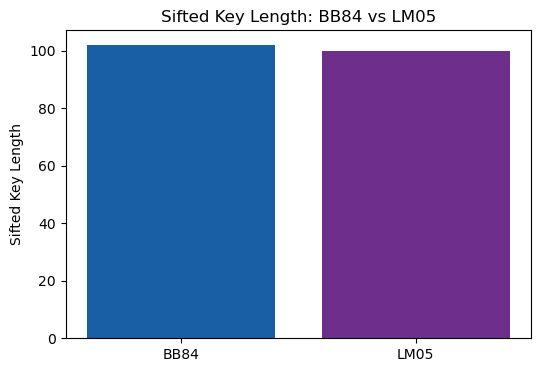

In [6]:
# Step 6: Bar chart — sifted key length comparison

protocols = ['BB84', 'LM05']
key_lengths = [len(alice_sifted_bb84), len(alice_sifted_lm05)]

plt.figure(figsize=(6, 4))
plt.bar(protocols, key_lengths, color=['#185FA5', '#6E2E8C'])
plt.ylabel('Sifted Key Length')
plt.title('Sifted Key Length: BB84 vs LM05')
plt.show()

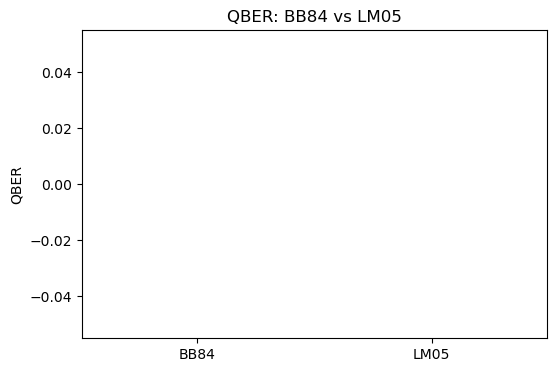

In [7]:
# Step 7: Bar chart — QBER comparison

qber_values = [qber_bb84, qber_lm05]

plt.figure(figsize=(6, 4))
plt.bar(protocols, qber_values, color=['#185FA5', '#6E2E8C'])
plt.ylabel('QBER')
plt.title('QBER: BB84 vs LM05')
plt.show()

In [8]:
# Step 8: Calculate SKR for both protocols

def binary_entropy(p):
    if p == 0 or p == 1:
        return 0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

f_EC = 1.16   # typical error-correction inefficiency factor

# BB84 SKR
skr_fraction_bb84 = max(1 - f_EC * binary_entropy(qber_bb84) - binary_entropy(qber_bb84), 0)
final_key_length_bb84 = skr_fraction_bb84 * len(alice_sifted_bb84)

# LM05 SKR
skr_fraction_lm05 = max(1 - f_EC * binary_entropy(qber_lm05) - binary_entropy(qber_lm05), 0)
final_key_length_lm05 = skr_fraction_lm05 * len(alice_sifted_lm05)

print(f"BB84 final secure key length : {final_key_length_bb84:.1f} bits")
print(f"LM05 final secure key length : {final_key_length_lm05:.1f} bits")

BB84 final secure key length : 102.0 bits
LM05 final secure key length : 100.0 bits


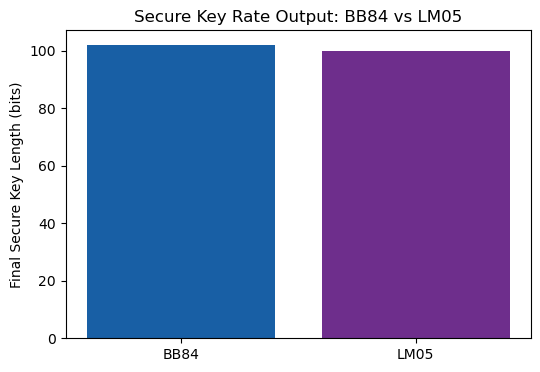

In [9]:
# Step 9: Bar chart — SKR comparison

skr_lengths = [final_key_length_bb84, final_key_length_lm05]

plt.figure(figsize=(6, 4))
plt.bar(protocols, skr_lengths, color=['#185FA5', '#6E2E8C'])
plt.ylabel('Final Secure Key Length (bits)')
plt.title('Secure Key Rate Output: BB84 vs LM05')
plt.show()

In [10]:
# Step 10: Final combined results table

print("=" * 65)
print("FINAL COMPARISON — BB84 vs LM05 (Level 1: Ideal Simulator)")
print("=" * 65)
print(f"{'Metric':<25}{'BB84':<20}{'LM05':<20}")
print("-" * 65)
print(f"{'Raw qubits sent':<25}{N_BITS:<20}{N_BITS:<20}")
print(f"{'Sifted key length':<25}{len(alice_sifted_bb84):<20}{len(alice_sifted_lm05):<20}")
print(f"{'QBER':<25}{qber_bb84:<20.4f}{qber_lm05:<20.4f}")
print(f"{'SKR fraction/bit':<25}{skr_fraction_bb84:<20.4f}{skr_fraction_lm05:<20.4f}")
print(f"{'Final secure key (bits)':<25}{final_key_length_bb84:<20.1f}{final_key_length_lm05:<20.1f}")

FINAL COMPARISON — BB84 vs LM05 (Level 1: Ideal Simulator)
Metric                   BB84                LM05                
-----------------------------------------------------------------
Raw qubits sent          200                 200                 
Sifted key length        102                 100                 
QBER                     0.0000              0.0000              
SKR fraction/bit         1.0000              1.0000              
Final secure key (bits)  102.0               100.0               
